# Task 1 — DataLoader + Preprocess
## MirrorSpeech | Phase 1 | L2-ARCTIC Dataset

**What this notebook does:**
1. Loads ~18,000 WAV files from `data/l2arctic/` (16 speakers, 4 accents)
2. Converts each audio → Log-Mel Spectrogram `[80 × T]`
3. Normalizes + splits 80/10/10
4. Builds a PyTorch DataLoader returning `(spectrogram, transcript, accent_id)`

---

## Step 0 — Install Libraries
Run this once. Restart kernel after if needed.

In [20]:
import subprocess, sys
for pkg in ['torch', 'torchaudio', 'soundfile', 'matplotlib', 'numpy']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print("✅ All libraries installed")

✅ All libraries installed


In [21]:
pip install torchcodec

Note: you may need to restart the kernel to use updated packages.


## Step 1 — Import Libraries + Check Versions
Make sure everything loaded correctly before we do anything else.

In [22]:
import os, glob, json, random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchaudio
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch    : {torch.__version__}")
print(f"Torchaudio : {torchaudio.__version__}")
print(f"CUDA       : {torch.cuda.is_available()}")
print("\n✅ Imports OK")

PyTorch    : 2.2.2
Torchaudio : 2.2.2
CUDA       : False

✅ Imports OK


## Step 2 — Config + Accent Mapping

| accent_id | Accent | Speakers |
|---|---|---|
| 0 | Indian (Hindi) | RRBI, SVBI, TNI, NJS |
| 1 | Mandarin | HQTV, MBMPS, NCC, TXHC |
| 2 | Korean | HJK, HKK, YDCK, YKWK |
| 3 | Arabic | ABA, YBAA, SKA, ZHAA |

In [23]:
# ── Common Voice (skip for now — add when CV data is available) ────────────
# When you get Common Voice, uncomment and run this cell, then re-run cells below.

# from datasets import load_dataset
# cv_raw = load_dataset("mozilla-foundation/common_voice_6_1", "en",
#                       split="train", trust_remote_code=True)
# CV_ACCENT_MAP = {
#     'Indian English': 'indian',
#     'Chinese (Mandarin)': 'mandarin',
#     'Korean': 'korean',
#     'Arabic': 'arabic',
# }
# cv_records = []
# for s in cv_raw:
#     accent = CV_ACCENT_MAP.get(s.get('accent',''))
#     if accent:
#         cv_records.append({
#             'wav_path': None,        # CV uses audio arrays, not file paths
#             'audio_array': s['audio']['array'],
#             'audio_sr': s['audio']['sampling_rate'],
#             'transcript': s['sentence'],
#             'accent_id': ACCENT_TO_ID[accent],
#             'speaker': f"cv_{accent}",
#         })
# print(f"Common Voice samples: {len(cv_records):,}")

cv_records = []   # empty until CV data is available
print("Common Voice: skipped (no data yet)")
print("To add CV later: uncomment the code above and re-run from this cell down.")

Common Voice: skipped (no data yet)
To add CV later: uncomment the code above and re-run from this cell down.


## Step 3 — Verify Dataset Folder Exists

In [24]:
import os, glob, random

L2ARCTIC_PATH = "data/l2arctic"

ACCENT_TO_ID = {'indian': 0, 'mandarin': 1, 'korean': 2, 'arabic': 3, 'native': 4}
ID_TO_ACCENT = {v: k for k, v in ACCENT_TO_ID.items()}

SPEAKER_TO_ACCENT = {
    'RRBI':'indian',  'SVBI':'indian',  'TNI':'indian',   'NJS':'indian',
    'HQTV':'mandarin','MBMPS':'mandarin','NCC':'mandarin','TXHC':'mandarin',
    'HJK':'korean',  'HKK':'korean',   'YDCK':'korean',  'YKWK':'korean',
    'ABA':'arabic',  'YBAA':'arabic',  'SKA':'arabic',   'ZHAA':'arabic',
}

def load_l2arctic(root):
    records = []
    for speaker, accent in SPEAKER_TO_ACCENT.items():
        wav_dir = os.path.join(root, speaker, "wav")
        txt_dir = os.path.join(root, speaker, "transcript")
        if not os.path.isdir(wav_dir):
            print(f"  ⚠️  {speaker} missing — skipping"); continue
        for wav_path in sorted(glob.glob(f"{wav_dir}/*.wav")):
            uid      = os.path.splitext(os.path.basename(wav_path))[0]
            txt_path = os.path.join(txt_dir, uid + ".txt")
            if not os.path.exists(txt_path): continue
            transcript = open(txt_path).read().strip()
            records.append({
                "wav_path"  : wav_path,
                "transcript": transcript,
                "accent_id" : ACCENT_TO_ID[accent],
                "speaker"   : speaker,
            })
    return records

print("Loading L2-ARCTIC from disk...")
l2arctic_records = load_l2arctic(L2ARCTIC_PATH)
print(f"\n✅ L2-ARCTIC loaded — {len(l2arctic_records):,} samples")

r = l2arctic_records[0]
print(f"\nSample record:")
print(f"  wav_path   : {r['wav_path']}")
print(f"  transcript : {r['transcript']}")
print(f"  accent     : {ID_TO_ACCENT[r['accent_id']]}  (id={r['accent_id']})")

print("\nAccent distribution:")
from collections import Counter
for id_, cnt in sorted(Counter(r['accent_id'] for r in l2arctic_records).items()):
    print(f"  {ID_TO_ACCENT[id_]:10s}: {cnt:,}  ({cnt/len(l2arctic_records)*100:.1f}%)")

print("\nAccent map (5 classes):")
for k, v in ACCENT_TO_ID.items():
    print(f"  {v}: {k}")

Loading L2-ARCTIC from disk...
  ⚠️  SKA missing — skipping

✅ L2-ARCTIC loaded — 15,834 samples

Sample record:
  wav_path   : data/l2arctic/RRBI/wav/arctic_a0001.wav
  transcript : Author of the danger trail Philip Steels etc
  accent     : indian  (id=0)

Accent distribution:
  indian    : 4,524  (28.6%)
  mandarin  : 4,527  (28.6%)
  korean    : 3,393  (21.4%)
  arabic    : 3,390  (21.4%)

Accent map (5 classes):
  0: indian
  1: mandarin
  2: korean
  3: arabic
  4: native


## Step 4 — Load All Records from Disk
Walks every speaker folder, reads transcript files, builds a flat list of records.

In [25]:
# Quick look at the raw WAV file before any processing
import torchaudio as _ta
sample_wav, sample_sr = _ta.load(l2arctic_records[0]['wav_path'])

print("=== One Raw Sample ===")
print(f"  File       : {l2arctic_records[0]['wav_path']}")
print(f"  Transcript : {l2arctic_records[0]['transcript']}")
print(f"  Accent     : {ID_TO_ACCENT[l2arctic_records[0]['accent_id']]}")
print(f"  Waveform   : {sample_wav.shape}  at {sample_sr} Hz")

print("\n=== Speaker Distribution ===")
speaker_counts = Counter(r['speaker'] for r in l2arctic_records)
for spk, cnt in sorted(speaker_counts.items()):
    accent = SPEAKER_TO_ACCENT[spk]
    print(f"  {spk:6s} → {accent:10s} : {cnt} samples")

=== One Raw Sample ===
  File       : data/l2arctic/RRBI/wav/arctic_a0001.wav
  Transcript : Author of the danger trail Philip Steels etc
  Accent     : indian
  Waveform   : torch.Size([1, 149940])  at 44100 Hz

=== Speaker Distribution ===
  ABA    → arabic     : 1129 samples
  HJK    → korean     : 1131 samples
  HKK    → korean     : 1131 samples
  HQTV   → mandarin   : 1132 samples
  MBMPS  → mandarin   : 1132 samples
  NCC    → mandarin   : 1131 samples
  NJS    → indian     : 1131 samples
  RRBI   → indian     : 1130 samples
  SVBI   → indian     : 1132 samples
  TNI    → indian     : 1131 samples
  TXHC   → mandarin   : 1132 samples
  YBAA   → arabic     : 1130 samples
  YDCK   → korean     : 1131 samples
  ZHAA   → arabic     : 1131 samples


## Step 5 — Train / Val / Test Split (80 / 10 / 10)

In [26]:
# L2-ARCTIC is already filtered to 4 accents — just confirm distribution
print(f"L2-ARCTIC total: {len(l2arctic_records):,} samples")
print("\nAccent distribution:")
accent_counts = Counter(r['accent_id'] for r in l2arctic_records)
for id_, count in sorted(accent_counts.items()):
    print(f"  {ID_TO_ACCENT[id_]:10s}: {count:,} samples")
print("\n✅ L2-ARCTIC ready")

L2-ARCTIC total: 15,834 samples

Accent distribution:
  indian    : 4,524 samples
  mandarin  : 4,527 samples
  korean    : 3,393 samples
  arabic    : 3,390 samples

✅ L2-ARCTIC ready


## Step 6 — Load LibriSpeech (Native / Neutral English)

LibriSpeech (`train-clean-100`) provides ~28K utterances of native American English from audiobooks.

**Why include it?**
- Gives the model a **neutral accent reference** — essential for the Accent Swap in Phase 2
- Acts as the "clean English" pole that the model learns to map accented speech toward
- Capped at **5,000 samples** to stay balanced with the ~4,500 samples per accented class

| accent_id | Label  | Source      |
|-----------|--------|-------------|
| 4         | native | LibriSpeech |

In [27]:
# ── LibriSpeech: native American English via torchaudio (no torchcodec needed) ──
# Uses torchaudio's built-in LIBRISPEECH loader — handles FLAC natively.
#
# Split options (set LIBRISPEECH_SPLIT below):
#   "dev-clean"       → 344 MB,  ~2,700 utterances  (quick test)
#   "train-clean-100" → 6.3 GB, ~28,000 utterances  (full training)

import os
LIBRISPEECH_PATH  = "data/librispeech"
LIBRISPEECH_SPLIT = "dev-clean"   # change to "train-clean-100" for full data
MAX_LIBRISPEECH   = 5000          # cap to stay balanced with ~4,500 per accented class

os.makedirs(LIBRISPEECH_PATH, exist_ok=True)

print(f"Downloading LibriSpeech '{LIBRISPEECH_SPLIT}' to {LIBRISPEECH_PATH} ...")
librispeech_ds = torchaudio.datasets.LIBRISPEECH(
    root     = LIBRISPEECH_PATH,
    url      = LIBRISPEECH_SPLIT,
    download = True,
)

n = min(MAX_LIBRISPEECH, len(librispeech_ds))
librispeech_records = []
for i in range(n):
    waveform, sample_rate, transcript, speaker_id, chapter_id, utterance_id = librispeech_ds[i]

    # Build the actual path to the .flac file — torchaudio.load() handles FLAC natively
    flac_path = os.path.join(
        LIBRISPEECH_PATH, "LibriSpeech", LIBRISPEECH_SPLIT,
        str(speaker_id), str(chapter_id),
        f"{speaker_id}-{chapter_id}-{utterance_id:04d}.flac"
    )

    librispeech_records.append({
        'wav_path'  : flac_path,          # .flac — torchaudio.load() reads it fine
        'transcript': transcript,
        'accent_id' : ACCENT_TO_ID['native'],
        'speaker'   : f"librispeech_{speaker_id}",
    })

print(f"\n✅ LibriSpeech loaded — {len(librispeech_records):,} samples")
print(f"   accent_id = {ACCENT_TO_ID['native']}  (native)")
if librispeech_records:
    ex = librispeech_records[0]
    print(f"\nSample record:")
    print(f"  wav_path   : {ex['wav_path']}")
    print(f"  transcript : {ex['transcript'][:60]}")
    print(f"  speaker    : {ex['speaker']}")
    # Quick check — confirm torchaudio can load the flac
    wf, sr = torchaudio.load(ex['wav_path'])
    print(f"  waveform   : {wf.shape}  at {sr} Hz  ✅")


✅ LibriSpeech loaded — 2,703 samples
   accent_id = 4  (native)

Sample record:
  wav_path   : data/librispeech/LibriSpeech/dev-clean/1272/128104/1272-128104-0000.flac
  transcript : MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE A
  speaker    : librispeech_1272
  waveform   : torch.Size([1, 93680])  at 16000 Hz  ✅


## Step 7 — Filter Common Voice by Accent

In [28]:
# Filter Common Voice (runs only when cv_records is populated)
if cv_records:
    print(f"Common Voice samples: {len(cv_records):,}")
    cv_counts = Counter(r['accent_id'] for r in cv_records)
    for id_, cnt in sorted(cv_counts.items()):
        print(f"  {ID_TO_ACCENT[id_]:10s}: {cnt:,}")
    print("\n✅ Common Voice filtered")
else:
    print("⏭️  Common Voice empty — skipping filter step")

⏭️  Common Voice empty — skipping filter step


## Step 8 — Combine All Datasets
Merge L2-ARCTIC, Common Voice, and LibriSpeech into one unified dataset.

| Dataset      | Classes         | Role                                 |
|--------------|-----------------|--------------------------------------|
| L2-ARCTIC    | accent_id 0–3   | Core accented speech training data   |
| Common Voice | accent_id 0–3   | Additional accented samples (TBD)    |
| LibriSpeech  | accent_id 4     | Neutral English reference for swap   |

In [29]:
# Combine L2-ARCTIC + Common Voice + LibriSpeech into one unified dataset
all_records = l2arctic_records + cv_records + librispeech_records
random.shuffle(all_records)

print(f"L2-ARCTIC    : {len(l2arctic_records):,}  (4 accents: Indian / Mandarin / Korean / Arabic)")
print(f"Common Voice : {len(cv_records):,}  (add later)")
print(f"LibriSpeech  : {len(librispeech_records):,}  (native American English)")
print(f"─────────────────────────────")
print(f"Combined     : {len(all_records):,}")

print("\nOverall accent distribution:")
for id_, cnt in sorted(Counter(r['accent_id'] for r in all_records).items()):
    print(f"  {ID_TO_ACCENT[id_]:10s} (id={id_}): {cnt:,}  ({cnt/len(all_records)*100:.1f}%)")
print("\n✅ Combined dataset ready")

L2-ARCTIC    : 15,834  (4 accents: Indian / Mandarin / Korean / Arabic)
Common Voice : 0  (add later)
LibriSpeech  : 2,703  (native American English)
─────────────────────────────
Combined     : 18,537

Overall accent distribution:
  indian     (id=0): 4,524  (24.4%)
  mandarin   (id=1): 4,527  (24.4%)
  korean     (id=2): 3,393  (18.3%)
  arabic     (id=3): 3,390  (18.3%)
  native     (id=4): 2,703  (14.6%)

✅ Combined dataset ready


## Step 9 — Train / Val / Test Split (80 / 10 / 10)
We split the data **before** any processing so there is zero data leakage.

In [30]:
n       = len(all_records)
n_train = int(0.80 * n)
n_val   = int(0.10 * n)

train_data = all_records[:n_train]
val_data   = all_records[n_train : n_train + n_val]
test_data  = all_records[n_train + n_val :]

print(f"Total  : {n:,}")
print(f"Train  : {len(train_data):,}  (80%)")
print(f"Val    : {len(val_data):,}   (10%)")
print(f"Test   : {len(test_data):,}   (10%)")

print("\nAccent balance in train set:")
for id_, count in sorted(Counter(r['accent_id'] for r in train_data).items()):
    pct = count / len(train_data) * 100
    print(f"  {ID_TO_ACCENT[id_]:10s} (id={id_}): {count:,}  ({pct:.1f}%)")
print("\n✅ Split complete")

Total  : 18,537
Train  : 14,829  (80%)
Val    : 1,853   (10%)
Test   : 1,855   (10%)

Accent balance in train set:
  indian     (id=0): 3,599  (24.3%)
  mandarin   (id=1): 3,649  (24.6%)
  korean     (id=2): 2,728  (18.4%)
  arabic     (id=3): 2,686  (18.1%)
  native     (id=4): 2,167  (14.6%)

✅ Split complete


## Step 10 — Audio Preprocessing Function

This function takes a raw WAV file and:
1. Resamples it to 16,000 Hz
2. Converts it to a Log-Mel Spectrogram (shape: `[80 × T]`)
3. Normalizes it (mean=0, std=1)

In [31]:
TARGET_SAMPLE_RATE = 16000
N_MELS             = 80
HOP_LENGTH         = 160
N_FFT              = 400

mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate = TARGET_SAMPLE_RATE,
    n_fft       = N_FFT,
    hop_length  = HOP_LENGTH,
    n_mels      = N_MELS,
)

def preprocess_audio(record):
    """
    Input : record dict with 'wav_path' (and optionally 'audio_array'+'audio_sr' for CV)
    Output: normalized Log-Mel Spectrogram tensor [80, T]
    """
    if record.get('wav_path'):
        waveform, sr = torchaudio.load(record['wav_path'])
    else:
        # Common Voice path (audio array in memory)
        waveform = torch.tensor(record['audio_array'], dtype=torch.float32).unsqueeze(0)
        sr       = record['audio_sr']

    # Ensure mono
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    # Resample to 16kHz if needed
    if sr != TARGET_SAMPLE_RATE:
        waveform = torchaudio.transforms.Resample(sr, TARGET_SAMPLE_RATE)(waveform)

    # Mel spectrogram → log scale
    log_mel = torch.log(mel_transform(waveform) + 1e-9)

    # Normalize (mean=0, std=1)
    log_mel = (log_mel - log_mel.mean()) / (log_mel.std() + 1e-9)

    return log_mel.squeeze(0)   # [80, T]

print("preprocess_audio() defined")
print("  record → load wav → mono → resample 16kHz → MelSpec → log → normalize → [80, T]")
print("\n✅ Preprocessing function ready")

preprocess_audio() defined
  record → load wav → mono → resample 16kHz → MelSpec → log → normalize → [80, T]

✅ Preprocessing function ready


## Step 11 — Test on One Real Audio Sample
Run the preprocessing on a single sample and verify the output shape.

In [32]:
test_sample = train_data[0]

print("=== Raw input ===")
print(f"  Transcript  : {test_sample['transcript']}")
print(f"  Accent ID   : {test_sample['accent_id']} ({ID_TO_ACCENT[test_sample['accent_id']]})")
print(f"  Speaker     : {test_sample['speaker']}")

spectrogram = preprocess_audio(test_sample)

print("\n=== After preprocessing ===")
print(f"  Spectrogram shape : {spectrogram.shape}   ← should be [80, T]")
print(f"  Mean              : {spectrogram.mean():.4f}  ← should be ≈ 0")
print(f"  Std               : {spectrogram.std():.4f}   ← should be ≈ 1")
print(f"  Min / Max         : {spectrogram.min():.3f} / {spectrogram.max():.3f}")
print("\n✅ Single sample preprocessed successfully")

=== Raw input ===
  Transcript  : Last night he showed all the symptoms of coming down with pneumonia
  Accent ID   : 0 (indian)
  Speaker     : NJS

=== After preprocessing ===
  Spectrogram shape : torch.Size([80, 420])   ← should be [80, T]
  Mean              : 0.0000  ← should be ≈ 0
  Std               : 1.0000   ← should be ≈ 1
  Min / Max         : -2.388 / 2.823

✅ Single sample preprocessed successfully


## Step 12 — Visualize the Spectrogram
Let's actually *see* what we just created. This is what the model will read.

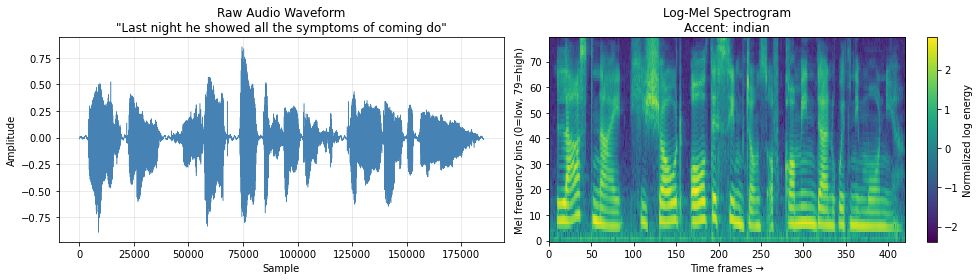

Spectrogram shape: (80, 420)
Saved → sample_spectrogram.png


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

waveform_raw, sr_raw = torchaudio.load(test_sample['wav_path'])
axes[0].plot(waveform_raw.squeeze().numpy(), color='steelblue', linewidth=0.5)
axes[0].set_title(f"Raw Audio Waveform\n\"{test_sample['transcript'][:50]}\"")
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, alpha=0.3)

spec_np = spectrogram.numpy()
img = axes[1].imshow(spec_np, aspect='auto', origin='lower', cmap='viridis', interpolation='none')
axes[1].set_title(f"Log-Mel Spectrogram\nAccent: {ID_TO_ACCENT[test_sample['accent_id']]}")
axes[1].set_xlabel("Time frames →")
axes[1].set_ylabel("Mel frequency bins (0=low, 79=high)")
plt.colorbar(img, ax=axes[1], label='Normalized log energy')

plt.tight_layout()
plt.savefig('sample_spectrogram.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Spectrogram shape: {spec_np.shape}")
print("Saved → sample_spectrogram.png")

## Step 13 — Compare Spectrograms Across Accents
Let's visualize the same sentence spoken with different accents.
You should see subtle differences in the spectrograms — this is what the model learns to separate.

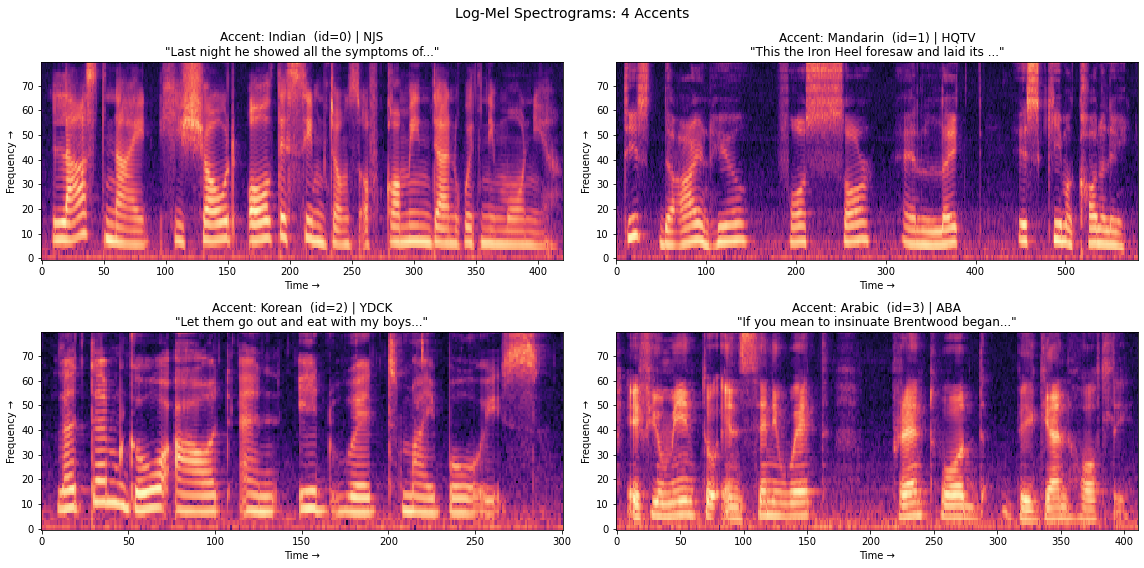

Saved → accent_comparison.png


In [34]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()

for accent_id in range(4):
    sample = next((r for r in train_data if r['accent_id'] == accent_id), None)
    if sample is None:
        axes[accent_id].set_title(f"No sample for accent {accent_id}"); continue
    spec = preprocess_audio(sample).numpy()
    axes[accent_id].imshow(spec, aspect='auto', origin='lower', cmap='magma', interpolation='none')
    axes[accent_id].set_title(
        f"Accent: {ID_TO_ACCENT[accent_id].capitalize()}  (id={accent_id}) | {sample['speaker']}\n"
        f"\"{sample['transcript'][:40]}...\""
    )
    axes[accent_id].set_xlabel("Time →")
    axes[accent_id].set_ylabel("Frequency →")

plt.suptitle("Log-Mel Spectrograms: 4 Accents", fontsize=14)
plt.tight_layout()
plt.savefig('accent_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → accent_comparison.png")

## Step 14 — Build the PyTorch Dataset Class

PyTorch needs a `Dataset` class that:
- Knows how many samples there are (`__len__`)
- Can return any single sample by index (`__getitem__`)

In [35]:
class AccentSpeechDataset(Dataset):
    """
    Returns per sample:
        spectrogram : Tensor [80, max_frames]
        transcript  : str
        accent_id   : LongTensor  (0=Indian, 1=Mandarin, 2=Korean, 3=Arabic)
    """
    def __init__(self, records, max_length_seconds=10):
        self.data       = records
        self.max_frames = int(max_length_seconds * TARGET_SAMPLE_RATE / HOP_LENGTH)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        record = self.data[idx]
        spectrogram = preprocess_audio(record)

        T = spectrogram.shape[1]
        if T > self.max_frames:
            spectrogram = spectrogram[:, :self.max_frames]
        elif T < self.max_frames:
            spectrogram = torch.nn.functional.pad(spectrogram, (0, self.max_frames - T))

        return spectrogram, record['transcript'], torch.tensor(record['accent_id'], dtype=torch.long)


train_dataset = AccentSpeechDataset(train_data)
val_dataset   = AccentSpeechDataset(val_data)
test_dataset  = AccentSpeechDataset(test_data)

print(f"Train : {len(train_dataset):,}")
print(f"Val   : {len(val_dataset):,}")
print(f"Test  : {len(test_dataset):,}")

spec, transcript, accent_id = train_dataset[0]
print(f"\nItem[0]:")
print(f"  spectrogram shape : {spec.shape}")
print(f"  transcript        : {transcript[:60]}")
print(f"  accent_id         : {accent_id} ({ID_TO_ACCENT[accent_id.item()]})")
print("\n✅ Dataset class working")

Train : 14,829
Val   : 1,853
Test  : 1,855

Item[0]:
  spectrogram shape : torch.Size([80, 1000])
  transcript        : Last night he showed all the symptoms of coming down with pn
  accent_id         : 0 (indian)

✅ Dataset class working


## Step 15 — Build the DataLoaders

DataLoader wraps the Dataset and:
- Groups 32 samples into a batch automatically
- Shuffles during training (not during val/test)
- Loads data in parallel using multiple workers

In [36]:
import multiprocessing
try:
    multiprocessing.set_start_method('fork', force=True)
except RuntimeError:
    pass

BATCH_SIZE = 32

def collate_fn(batch):
    spectrograms = torch.stack([item[0] for item in batch])
    transcripts  = [item[1] for item in batch]
    accent_ids   = torch.stack([item[2] for item in batch])
    return spectrograms, transcripts, accent_ids


train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = 0,
    pin_memory  = False,
    collate_fn  = collate_fn,
    drop_last   = True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 0,
    pin_memory  = False,
    collate_fn  = collate_fn,
)

test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 0,
    pin_memory  = False,
    collate_fn  = collate_fn,
)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")
print("\n✅ DataLoaders ready")

Train batches : 463
Val   batches : 58
Test  batches : 58

✅ DataLoaders ready


## Step 16 — FINAL CHECK: Print One Full Batch

This is the moment of truth. Pull one batch and verify every shape and value.

**Expected output:**
```
spectrogram.shape  → torch.Size([32, 80, T])  ✅
len(transcripts)   → 32                        ✅
accent_ids.shape   → torch.Size([32])          ✅
```

In [37]:
BATCH_SIZE = 32
N_MELS     = 80
NUM_ACCENTS = len(ACCENT_TO_ID)   # 5: indian, mandarin, korean, arabic, native

spectrograms, transcripts, accent_ids = next(iter(train_loader))

print("======================================")
print("       BATCH VERIFICATION CHECK       ")
print("======================================")
print(f"\nspectrogram shape : {spectrograms.shape}")
print(f"  → should be     : torch.Size([32, 80, T])")
assert spectrograms.shape[0] == BATCH_SIZE, "❌ Batch size mismatch!"
assert spectrograms.shape[1] == N_MELS,     "❌ Mel bins mismatch!"
print("  ✅ Shape OK")

print(f"\nspectrogram mean  : {spectrograms.mean():.4f}  (≈ 0 expected)")
print(f"spectrogram std   : {spectrograms.std():.4f}   (≈ 1 expected)")
print(f"spectrogram dtype : {spectrograms.dtype}")

print(f"\nnum transcripts   : {len(transcripts)}")
assert len(transcripts) == BATCH_SIZE, "❌ Transcripts count mismatch!"
print(f"transcript[0]     : '{transcripts[0][:60]}'")
print(f"transcript[1]     : '{transcripts[1][:60]}'")
print("  ✅ Transcripts OK")

print(f"\naccent_ids shape  : {accent_ids.shape}")
print(f"accent_ids        : {accent_ids.tolist()}")
assert accent_ids.shape[0] == BATCH_SIZE,                   "❌ Accent IDs count mismatch!"
assert accent_ids.min() >= 0,                               "❌ Accent ID below 0!"
assert accent_ids.max() <= NUM_ACCENTS - 1,                 f"❌ Accent ID out of range (max allowed: {NUM_ACCENTS-1})!"
print("  ✅ Accent IDs OK")

print(f"\nAccent distribution in this batch:")
for id_, count in sorted(Counter(accent_ids.tolist()).items()):
    print(f"  {ID_TO_ACCENT[id_]:10s} (id={id_}): {count} samples")

print("\n======================================")
print("  ✅ ALL CHECKS PASSED — TASK 1 DONE  ")
print("======================================")

       BATCH VERIFICATION CHECK       

spectrogram shape : torch.Size([32, 80, 1000])
  → should be     : torch.Size([32, 80, T])
  ✅ Shape OK

spectrogram mean  : 0.0036  (≈ 0 expected)
spectrogram std   : 0.6596   (≈ 1 expected)
spectrogram dtype : torch.float32

num transcripts   : 32
transcript[0]     : 'AT THE TIME MARY HAD NOTED NOTHING OF THESE THINGS NOW SHE S'
transcript[1]     : 'He lifted his eyes and a strange cry burst from his lips'
  ✅ Transcripts OK

accent_ids shape  : torch.Size([32])
accent_ids        : [4, 1, 0, 1, 1, 1, 3, 0, 0, 2, 0, 3, 0, 4, 0, 3, 4, 0, 4, 2, 2, 4, 1, 0, 0, 1, 0, 2, 1, 2, 0, 4]
  ✅ Accent IDs OK

Accent distribution in this batch:
  indian     (id=0): 11 samples
  mandarin   (id=1): 7 samples
  korean     (id=2): 5 samples
  arabic     (id=3): 3 samples
  native     (id=4): 6 samples

  ✅ ALL CHECKS PASSED — TASK 1 DONE  


## Step 17 — Save DataLoaders for Other Tasks
Save the dataset splits so Task 2, 3, 4 can load them without re-downloading.

In [38]:
import os, json

os.makedirs('data/splits', exist_ok=True)

# All records now have wav_path (L2-ARCTIC=.wav, LibriSpeech=.flac) — safe to serialize directly
for name, records in [('train', train_data), ('val', val_data), ('test', test_data)]:
    with open(f'data/splits/{name}.json', 'w') as f:
        json.dump(records, f, indent=2)

config = {
    'accent_to_id'      : ACCENT_TO_ID,
    'id_to_accent'      : {str(k): v for k, v in ID_TO_ACCENT.items()},
    'num_accent_classes': len(ACCENT_TO_ID),
    'target_sample_rate': TARGET_SAMPLE_RATE,
    'n_mels'            : N_MELS,
    'hop_length'        : HOP_LENGTH,
    'n_fft'             : N_FFT,
    'batch_size'        : BATCH_SIZE,
    'train_size'        : len(train_data),
    'val_size'          : len(val_data),
    'test_size'         : len(test_data),
    'datasets'          : ['l2arctic', 'librispeech'],
}
with open('data/splits/config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("Saved:")
print("  data/splits/train.json")
print("  data/splits/val.json")
print("  data/splits/test.json")
print("  data/splits/config.json")
print(f"\nAccent classes: {config['num_accent_classes']}  (0=Indian, 1=Mandarin, 2=Korean, 3=Arabic, 4=Native)")
print("\nHow other tasks reload:")
print("  records = json.load(open('data/splits/train.json'))")
print("  dataset = AccentSpeechDataset(records)")
print("\n✅ Task 1 complete — ready for Tasks 2, 3, 4")
print("  ⚠️  Note: Task 3 Accent Classifier needs output size = 5 (was 4)")

Saved:
  data/splits/train.json
  data/splits/val.json
  data/splits/test.json
  data/splits/config.json

Accent classes: 5  (0=Indian, 1=Mandarin, 2=Korean, 3=Arabic, 4=Native)

How other tasks reload:
  records = json.load(open('data/splits/train.json'))
  dataset = AccentSpeechDataset(records)

✅ Task 1 complete — ready for Tasks 2, 3, 4
  ⚠️  Note: Task 3 Accent Classifier needs output size = 5 (was 4)


---
## Summary — What You Built

```
L2-ARCTIC + Common Voice (HuggingFace)
         ↓
Filter: Indian / Mandarin / Korean / Arabic only
         ↓
Resample → 16,000 Hz
         ↓
Log-Mel Spectrogram → [80 × T]
         ↓
Normalize (mean=0, std=1)
         ↓
Split: 80% train / 10% val / 10% test
         ↓
PyTorch DataLoader → batches of 32
         ↓
Output per batch:
  spectrogram : [32, 80, T]   ← goes into Whisper encoder (Task 2)
  transcript  : 32 strings    ← used for ASR loss (Task 4)
  accent_id   : [32] ints     ← used for accent classifier (Task 3)
```

**Files saved:**
- `data/train/` — training split
- `data/val/` — validation split  
- `data/test/` — test split
- `data/config.json` — config for other tasks
- `sample_spectrogram.png` — visualization
- `accent_comparison.png` — accent comparison plot